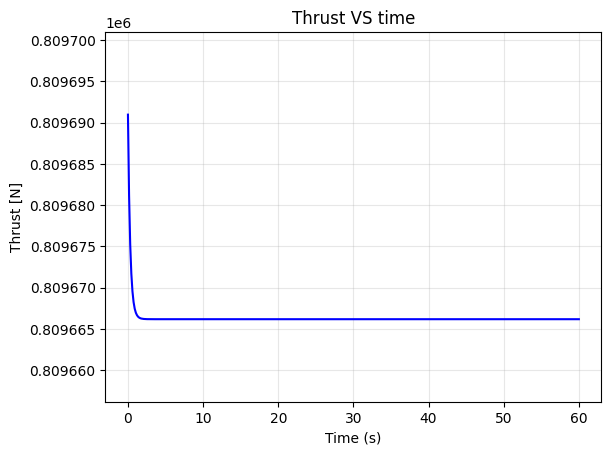

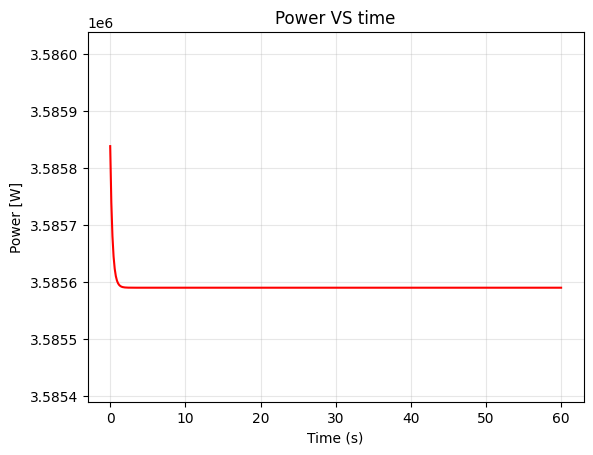

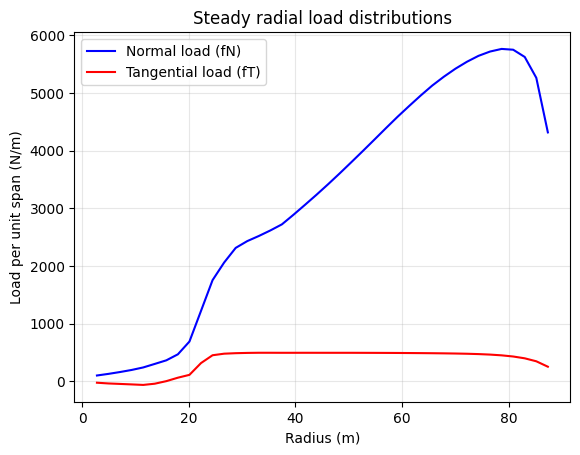

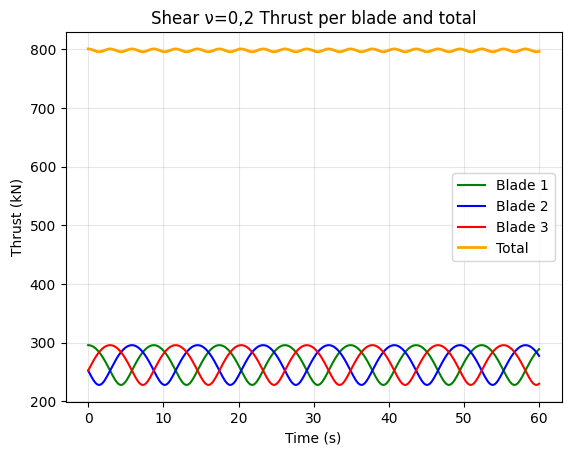

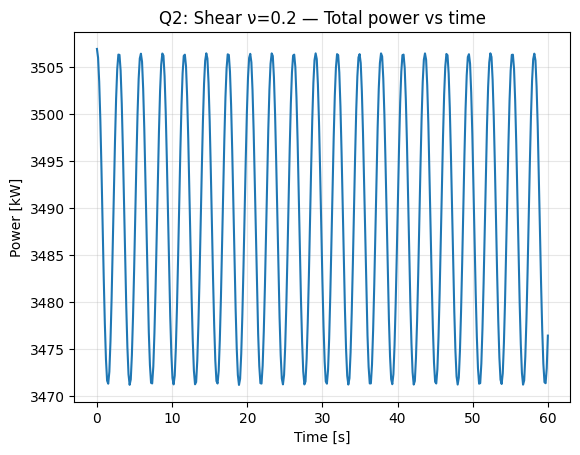

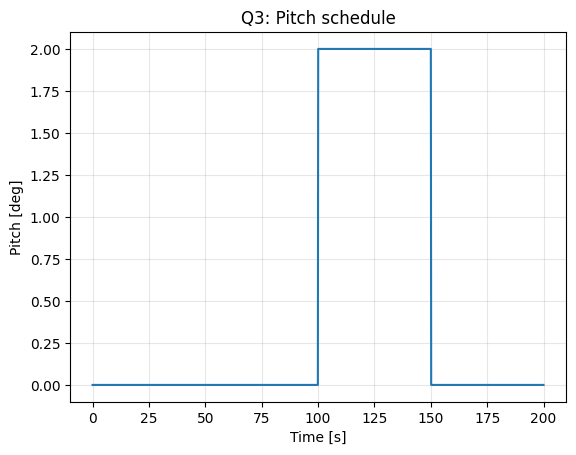

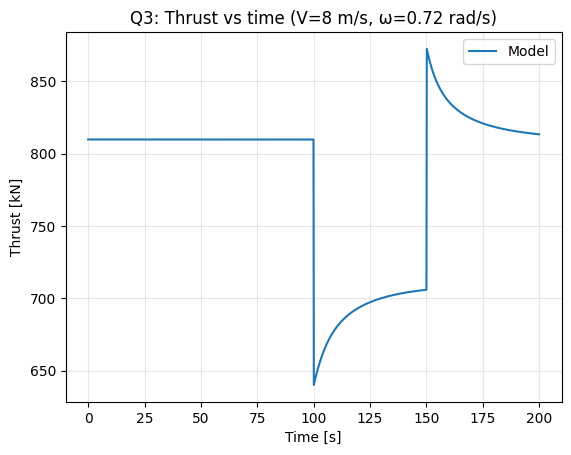

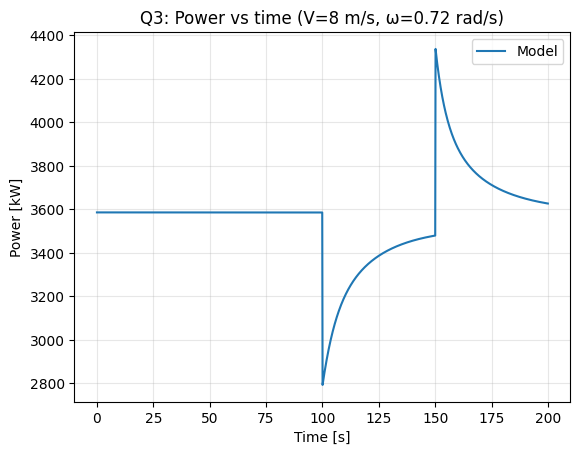

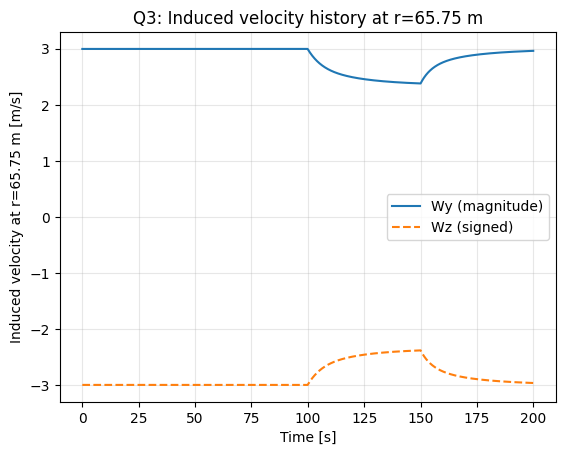

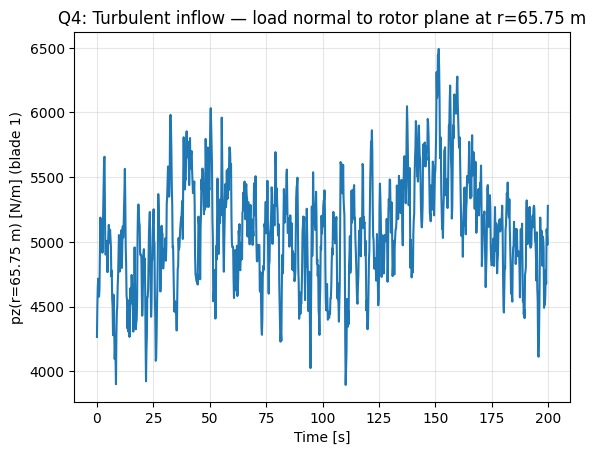

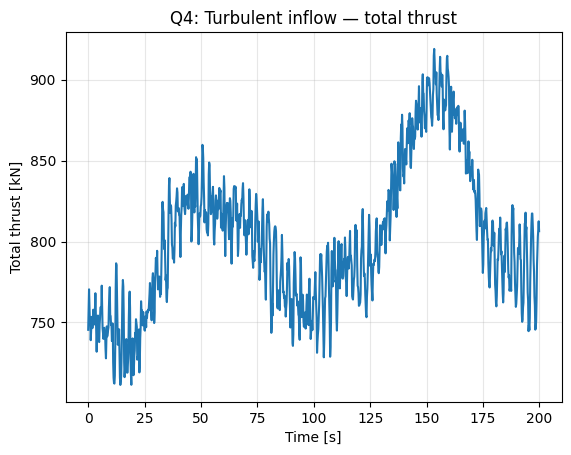

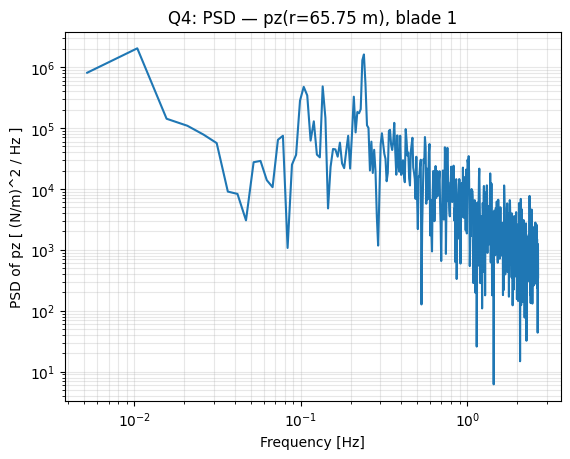

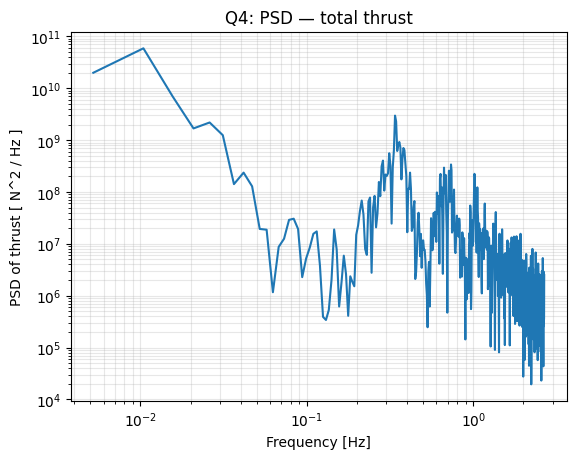

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

# =========================
# Assignment 1 – Q1 + Q2 + Q3
# uBEM-ready framework, loads computed like your TASK 4:
#   iterate a/ap -> Vrel -> L,D -> fN,fT
# =========================

# -------- Files (keep in same folder as this script) --------
DATA_DIR = "."
BLADE_FILE = os.path.join(DATA_DIR, "bladedat.txt")

AIRFOIL_FILES = {
    100.0: os.path.join(DATA_DIR, "cylinder_ds.txt"),
    24.1:  os.path.join(DATA_DIR, "FFA-W3-241_ds.txt"),
    30.1:  os.path.join(DATA_DIR, "FFA-W3-301_ds.txt"),
    36.0:  os.path.join(DATA_DIR, "FFA-W3-360_ds.txt"),
    48.0:  os.path.join(DATA_DIR, "FFA-W3-480_ds.txt"),
    60.0:  os.path.join(DATA_DIR, "FFA-W3-600_ds.txt"),
}

# -------- Turbine / case constants --------
R = 89.17
B = 3
rho = 1.225

# Operating point (assignment)
omega = 0.72
Vhub = 8.0

# Time (ASSUMPTIONS!)
dt = 0.15
T_end_Q1Q2 = 60.0
T_end_Q3 = 200.0

# Discretization (ASSUMPTION!)
Nsec = 40

# Q2 shear parameters
H_HUB = 119.0
SHEAR_EXP = 0.2

# Solver params (like your TASK 4) (ASSUMPTIONS!)
F_RELAX = 0.35
TOL_RES = 1e-4
ITMAX = 80

# Q3 dynamic inflow ON (Øye model)
USE_DYNAMIC_INFLOW_Q3 = True
OYE_K = 0.6                 # Øye model constant (k ≈ 0.6)
OYE_DENOM_MIN = 0.05        # safety clamp for (1 - 1.3 a) in tau1

# Warm start (recommended): avoids huge transient at t=0
WARM_START = True


# =========================
# Recorder
# =========================
@dataclass
class Recorder:
    t: list = field(default_factory=list)
    T_blades: list = field(default_factory=list)
    P_blades: list = field(default_factory=list)
    T_total: list = field(default_factory=list)
    P_total: list = field(default_factory=list)

    # optional (Q3)
    pitch_deg: list = field(default_factory=list)
    a_probe: list = field(default_factory=list)
    Vind_probe: list = field(default_factory=list)   # magnitude a*Vhub
    Wz_probe: list = field(default_factory=list)     # signed induced axial velocity = -a*Vhub

    def record(self, t, T_blades, P_blades, T_total, P_total,
               pitch_deg=np.nan, a_probe=np.nan, Vind_probe=np.nan, Wz_probe=np.nan):
        self.t.append(t)
        self.T_blades.append(np.array(T_blades, dtype=float))
        self.P_blades.append(np.array(P_blades, dtype=float))
        self.T_total.append(T_total)
        self.P_total.append(P_total)

        self.pitch_deg.append(pitch_deg)
        self.a_probe.append(a_probe)
        self.Vind_probe.append(Vind_probe)
        self.Wz_probe.append(Wz_probe)

    def as_arrays(self):
        return {
            "t": np.array(self.t, dtype=float),
            "T_blades": np.vstack(self.T_blades) if self.T_blades else np.zeros((0, 0)),
            "P_blades": np.vstack(self.P_blades) if self.P_blades else np.zeros((0, 0)),
            "T_total": np.array(self.T_total, dtype=float),
            "P_total": np.array(self.P_total, dtype=float),
            "pitch_deg": np.array(self.pitch_deg, dtype=float),
            "a_probe": np.array(self.a_probe, dtype=float),
            "Vind_probe": np.array(self.Vind_probe, dtype=float),
            "Wz_probe": np.array(self.Wz_probe, dtype=float),
        }


# =========================
# 1) Read blade geometry + build sections
# =========================
def read_bladedat(path):
    """
    MATCHING YOUR STEADY BEM ASSUMPTION:
      col0: r [m]
      col1: twist [deg]
      col2: chord [m]
      col3: t/c [%]   (or ratio)
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing blade file: {path}")

    data = np.loadtxt(path)
    if data.ndim != 2 or data.shape[1] < 4:
        raise ValueError("bladedat.txt must have >= 4 columns")

    r = data[:, 0]
    tc = data[:, 3]

    beta_deg = data[:, 1]   # twist [deg]
    c = data[:, 2]          # chord [m]

    if np.nanmax(tc) <= 1.5:
        tc = tc * 100.0

    idx = np.argsort(r)
    return r[idx], c[idx], beta_deg[idx], tc[idx]


def build_sections(r_tab, c_tab, beta_deg_tab, tc_tab, nsec):
    r0 = float(np.min(r_tab))
    Rtip = float(np.max(r_tab))
    r_sec = np.linspace(r0, 0.98 * Rtip, nsec)

    c_sec = np.interp(r_sec, r_tab, c_tab)
    beta_deg_sec = np.interp(r_sec, r_tab, beta_deg_tab)
    tc_sec = np.interp(r_sec, r_tab, tc_tab)
    return Rtip, r_sec, c_sec, beta_deg_sec, tc_sec


# =========================
# 2) Read polars + interpolation with extrapolation
# =========================
def read_polar_file(path):
    tbl = np.loadtxt(path, ndmin=2)
    if tbl.shape[1] < 3:
        raise ValueError(f"{path} must have >= 3 columns: alpha, Cl, Cd")
    alpha = tbl[:, 0]
    cl = tbl[:, 1]
    cd = tbl[:, 2]
    order = np.argsort(alpha)
    return alpha[order], cl[order], cd[order]


def load_airfoils(files_dict):
    items = sorted(files_dict.items(), key=lambda kv: kv[0])  # by tc%
    thick = np.array([tc for tc, _ in items], dtype=float)

    aoa_cols, cl_cols, cd_cols = [], [], []
    for tc, fname in items:
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing airfoil file: {fname}")
        a, cl, cd = read_polar_file(fname)
        aoa_cols.append(a)
        cl_cols.append(cl)
        cd_cols.append(cd)
    return thick, aoa_cols, cl_cols, cd_cols


THICK, AOA_COLS, CL_COLS, CD_COLS = load_airfoils(AIRFOIL_FILES)


def interp_extrap(x, xp, yp):
    x = float(x)
    xp = np.asarray(xp, dtype=float)
    yp = np.asarray(yp, dtype=float)

    if x <= xp[0]:
        x0, x1 = xp[0], xp[1]
        y0, y1 = yp[0], yp[1]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)
    if x >= xp[-1]:
        x0, x1 = xp[-2], xp[-1]
        y0, y1 = yp[-2], yp[-1]
        return y1 + (y1 - y0) * (x - x1) / (x1 - x0)
    return float(np.interp(x, xp, yp))


def cl_cd_double_interp(alpha_deg, tc_percent):
    tc = float(np.clip(tc_percent, THICK.min(), THICK.max()))
    cl_thk = np.empty(len(THICK))
    cd_thk = np.empty(len(THICK))

    for k in range(len(THICK)):
        cl_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CL_COLS[k])
        cd_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CD_COLS[k])

    cl = float(np.interp(tc, THICK, cl_thk))
    cd = float(np.interp(tc, THICK, cd_thk))
    return cl, cd


# =========================
# 3) Prandtl tip loss
# =========================
def prandtl_tip_loss(B, r, R, phi):
    sphi = abs(np.sin(phi))
    sphi = max(sphi, 1e-12)
    ftip = (B * (R - r)) / (2.0 * r * sphi)
    ftip = max(0.0, ftip)
    F = (2.0 / np.pi) * np.arccos(np.exp(-ftip))
    return float(np.clip(F, 1e-6, 1.0))


# =========================
# 4) Quasi-steady solve a/ap (TASK-4-style)
# =========================
def solve_a_ap_qs(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a_init, ap_init):
    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    a = a_init
    ap = ap_init

    a_new = 0.10 if a_init == 0.0 else a_init
    ap_new = 0.00 if ap_init == 0.0 else ap_init

    it = 0
    while True:
        it += 1
        a, ap = a_new, ap_new

        denom = (1.0 + ap) * Omega * r + 1e-12
        phi = np.arctan(((1.0 - a) * V0) / denom)
        alpha_deg = np.rad2deg(phi - (twist + theta_p))

        Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

        Cn = Cl * np.cos(phi) + Cd * np.sin(phi)
        Ct = Cl * np.sin(phi) - Cd * np.cos(phi)

        sigma = (B * chord) / (2.0 * np.pi * r + 1e-12)
        F = prandtl_tip_loss(B, r, R, phi)

        sphi = np.sin(phi)
        cphi = np.cos(phi)

        a_fix  = (sigma * Cn * (1.0 - a)) / (4.0 * F * (sphi ** 2) + 1e-12)
        ap_fix = (sigma * Ct * (1.0 + ap)) / (4.0 * F * sphi * cphi + 1e-12)

        if a > 0.33:
            dCT = ((1.0 - a) ** 2 * Cn * sigma) / (sphi ** 2 + 1e-12)
            a_fix = dCT / (4.0 * F * (1.0 - 0.25 * (5.0 - 3.0 * a) * a) + 1e-12)

        a_new  = a  + F_RELAX * (a_fix  - a)
        ap_new = ap + F_RELAX * (ap_fix - ap)

        if max(abs(a_fix - a), abs(ap_fix - ap)) < TOL_RES or it >= ITMAX:
            return a_new, ap_new


# =========================
# 5) Loads from a/ap (TASK-4-style projection using L and D)
# =========================
def loads_from_a_ap(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a, ap):
    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    denom = (1.0 + ap) * Omega * r + 1e-12
    phi = np.arctan(((1.0 - a) * V0) / denom)
    alpha_deg = np.rad2deg(phi - (twist + theta_p))

    Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

    Vrel = np.sqrt(((1.0 - a) * V0) ** 2 + ((1.0 + ap) * Omega * r) ** 2)
    L = 0.5 * rho * Vrel ** 2 * chord * Cl
    D = 0.5 * rho * Vrel ** 2 * chord * Cd

    fT = L * np.sin(phi) - D * np.cos(phi)
    fN = L * np.cos(phi) + D * np.sin(phi)
    return fN, fT


# =========================
# 6) Wind models
# =========================
def wind_constant(r_sec, Vhub):
    return np.full_like(r_sec, Vhub, dtype=float)


def wind_shear(r_sec, Vhub, H, nu, azimuth):
    z = H + r_sec * np.cos(azimuth)
    z = np.maximum(z, 1e-3)
    return Vhub * (z / H) ** nu


# =========================
# 7) Pitch schedule for Q3
# =========================
def pitch_schedule_deg(t):
    if t < 100.0:
        return 0.0
    if t <= 150.0:
        return 2.0
    return 0.0


# =========================
# 7b) Øye dynamic inflow time constants (Q3)
# =========================
def oye_time_constants(V0, a, r):
    """
    Øye dynamic inflow:
      tau1 = (1.1 / (1 - 1.3 a)) * (R / V0)
      tau2 = (0.39 - 0.26 (r/R)^2) * tau1
    """
    V0 = max(float(V0), 0.1)
    a = float(np.clip(a, 0.0, 0.95))
    denom = max(1.0 - 1.3 * a, OYE_DENOM_MIN)

    tau1 = (1.1 / denom) * (R / V0)
    tau2 = (0.39 - 0.26 * (r / R) ** 2) * tau1
    return float(tau1), float(max(tau2, 1e-6))


# =========================
# 8) Warm start induction (avoid huge initial transient)
# =========================
def warm_start_induction(a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg):
    for j in range(len(r_sec)):
        a_state[j], ap_state[j] = solve_a_ap_qs(
            Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
            a_state[j], ap_state[j]
        )


# =========================
# 9) Q1 simulation (constant wind, constant pitch)
# =========================
def run_Q1(r_sec, c_sec, beta_deg_sec, tc_sec):
    n_steps = int(np.floor(T_end_Q1Q2 / dt)) + 1

    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))

    Vz_local = wind_constant(r_sec, Vhub)

    if WARM_START:
        warm_start_induction(a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg=0.0)

    rec = Recorder()
    fN_last = np.zeros(len(r_sec))
    fT_last = np.zeros(len(r_sec))

    for k in range(n_steps):
        t = k * dt

        fN = np.zeros_like(r_sec)
        fT = np.zeros_like(r_sec)

        for j in range(len(r_sec)):
            a_qs, ap_qs = solve_a_ap_qs(
                Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], 0.0, tc_sec[j],
                a_state[j], ap_state[j]
            )
            a_state[j], ap_state[j] = a_qs, ap_qs
            fN[j], fT[j] = loads_from_a_ap(
                Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], 0.0, tc_sec[j],
                a_state[j], ap_state[j]
            )

        Tblade = np.trapezoid(fN, r_sec)
        Qblade = np.trapezoid(fT * r_sec, r_sec)
        Pblade = omega * Qblade

        Ttot = B * Tblade
        Ptot = B * Pblade

        rec.record(t, [Tblade], [Pblade], Ttot, Ptot)
        fN_last[:] = fN
        fT_last[:] = fT

    out = rec.as_arrays()
    out["r_sec"] = r_sec
    out["fN_last"] = fN_last
    out["fT_last"] = fT_last
    return out


# =========================
# 10) Q2 simulation (shear, 3 blades)
# =========================
def run_Q2(r_sec, c_sec, beta_deg_sec, tc_sec):
    n_steps = int(np.floor(T_end_Q1Q2 / dt)) + 1

    a_state = np.zeros((B, len(r_sec)))
    ap_state = np.zeros((B, len(r_sec)))

    # warm start at t=0 for each blade azimuth
    if WARM_START:
        for b in range(B):
            azim0 = 0.0 + 2.0 * np.pi * b / B
            Vz_local = wind_shear(r_sec, Vhub, H_HUB, SHEAR_EXP, azim0)
            warm_start_induction(a_state[b], ap_state[b], r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg=0.0)

    rec = Recorder()

    for k in range(n_steps):
        t = k * dt

        T_b = np.zeros(B)
        P_b = np.zeros(B)

        for b in range(B):
            azim = omega * t + 2.0 * np.pi * b / B
            Vz_local = wind_shear(r_sec, Vhub, H_HUB, SHEAR_EXP, azim)

            fN = np.zeros_like(r_sec)
            fT = np.zeros_like(r_sec)

            for j in range(len(r_sec)):
                a_qs, ap_qs = solve_a_ap_qs(
                    Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], 0.0, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )
                a_state[b, j], ap_state[b, j] = a_qs, ap_qs
                fN[j], fT[j] = loads_from_a_ap(
                    Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], 0.0, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )

            T_b[b] = np.trapezoid(fN, r_sec)
            Qblade = np.trapezoid(fT * r_sec, r_sec)
            P_b[b] = omega * Qblade

        Ttot = np.sum(T_b)
        Ptot = np.sum(P_b)
        rec.record(t, T_b, P_b, Ttot, Ptot)

    return rec.as_arrays()


# =========================
# 11) Q3 simulation (pitch step + Øye dynamic inflow at r=65.75)
# =========================
def run_Q3(r_sec, c_sec, beta_deg_sec, tc_sec, r_probe=65.75):
    n_steps = int(np.floor(T_end_Q3 / dt)) + 1

    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))

    Vz_local = wind_constant(r_sec, Vhub)

    # Øye states per radial element (axial induced velocity form)
    # Wz = -a*V0  (signed, typically negative)
    Wz_state = np.zeros(len(r_sec))
    Wint_state = np.zeros(len(r_sec))
    Wqs_prev = np.zeros(len(r_sec))

    # warm start at pitch=0
    if WARM_START:
        warm_start_induction(a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg=0.0)

    # initialise Øye states consistently with initial a_state
    Wz_state[:] = -a_state * Vz_local
    Wint_state[:] = Wz_state
    Wqs_prev[:] = Wz_state

    rec = Recorder()

    for k in range(n_steps):
        t = k * dt
        pitch = pitch_schedule_deg(t)

        fN = np.zeros_like(r_sec)
        fT = np.zeros_like(r_sec)

        for j in range(len(r_sec)):
            # --- quasi-steady BEM solution (equilibrium / target) ---
            a_qs, ap_qs = solve_a_ap_qs(
                Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch, tc_sec[j],
                a_state[j], ap_state[j]
            )

            if USE_DYNAMIC_INFLOW_Q3:
                # Convert to induced velocity form
                Wqs = -a_qs * Vz_local[j]

                # Øye time constants (use current actual a_state for tau1)
                tau1, tau2 = oye_time_constants(Vz_local[j], a_state[j], r_sec[j])

                fac1 = dt / tau1
                fac2 = dt / tau2

                # Øye discrete update
                Wint_state[j] = (
                    Wint_state[j]
                    + fac1 * (Wqs - Wint_state[j])
                    + OYE_K * (Wqs - Wqs_prev[j])
                )
                Wz_state[j] = Wz_state[j] + fac2 * (Wint_state[j] - Wz_state[j])

                # Store previous Wqs
                Wqs_prev[j] = Wqs

                # Back to induction factor (clipped for safety)
                a_state[j] = np.clip(-Wz_state[j] / max(Vz_local[j], 0.1), 0.0, 0.95)

                # Tangential induction kept quasi-steady (common assumption)
                ap_state[j] = ap_qs
            else:
                a_state[j], ap_state[j] = a_qs, ap_qs
                Wz_state[j] = -a_state[j] * Vz_local[j]
                Wint_state[j] = Wz_state[j]
                Wqs_prev[j] = Wz_state[j]

            # --- loads using the *actual* (filtered) induction ---
            fN[j], fT[j] = loads_from_a_ap(
                Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch, tc_sec[j],
                a_state[j], ap_state[j]
            )

        Tblade = np.trapezoid(fN, r_sec)
        Qblade = np.trapezoid(fT * r_sec, r_sec)
        Pblade = omega * Qblade

        Ttot = B * Tblade
        Ptot = B * Pblade

        # probe induction at r=65.75
        a_p = np.interp(r_probe, r_sec, a_state)
        Vind_mag = a_p * Vhub
        Wz_signed = -a_p * Vhub

        rec.record(t, [Tblade], [Pblade], Ttot, Ptot,
                   pitch_deg=pitch, a_probe=a_p, Vind_probe=Vind_mag, Wz_probe=Wz_signed)

    return rec.as_arrays()


# =========================
# 12) Plot helpers  
# =========================
def plot_Q1(out1):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    # Thrust (N) - tighter zoom
    T = out1["T_total"] 
    plt.figure()
    plt.plot(out1["t"], T, color="b")
    plt.xlabel("Time (s)")
    plt.ylabel("Thrust [N]")
    plt.title("Thrust VS time")
    plt.grid(True, alpha=0.3)

    pad = 10  # N (try 10, 20, 50)
    plt.ylim(T.min() - pad, T.max() + pad)

    ax = plt.gca()
    ax.ticklabel_format(axis="y", style="sci", scilimits=(6, 6), useOffset=False)

    # Power (W) - tighter zoom
    P = out1["P_total"] 
    plt.figure()
    plt.plot(out1["t"], P, color="r")
    plt.xlabel("Time (s)")
    plt.ylabel("Power [W]")
    plt.title("Power VS time")
    plt.grid(True, alpha=0.3)

    pad = 200 
    plt.ylim(P.min() - pad, P.max() + pad)

    ax = plt.gca()
    ax.ticklabel_format(axis="y", style="sci", scilimits=(6, 6), useOffset=False)


    # steady radial distributions (Q1 requirement) - ONE PLOT
    plt.figure()
    plt.plot(out1["r_sec"], out1["fN_last"], label="Normal load (fN)", color="b")
    plt.plot(out1["r_sec"], out1["fT_last"], label="Tangential load (fT)", color="r")
    plt.xlabel("Radius (m)")
    plt.ylabel("Load per unit span (N/m)")
    plt.title("Steady radial load distributions")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(outdir, "Q1_steady_radial_load_distributions.pdf"), bbox_inches="tight")


def plot_Q2(out2):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    # ---- Thrust per blade + total (kN) ----
    plt.figure()
    blade_colors = ["g", "b", "r"]
    for b in range(out2["T_blades"].shape[1]):
        plt.plot(
            out2["t"],
            out2["T_blades"][:, b] / 1e3,
            color=blade_colors[b],
            label=f"Blade {b+1}"
        )
    plt.plot(out2["t"], out2["T_total"] / 1e3, color="orange", lw=2, label="Total")
    plt.xlabel("Time (s)")
    plt.ylabel("Thrust (kN)")
    plt.title("Shear ν=0,2 Thrust per blade and total")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(outdir, "Q2_thrust_per_blade_and_total_kN.pdf"), bbox_inches="tight")

    # ---- Power (keep as is, kW) ----
    plt.figure()
    plt.plot(out2["t"], out2["P_total"] / 1e3)
    plt.xlabel("Time [s]")
    plt.ylabel("Power [kW]")
    plt.title("Q2: Shear ν=0.2 — Total power vs time")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "Q2_total_power_vs_time_kW.pdf"), bbox_inches="tight")


    # ---- Power zoomed out (kW, y from 0 to 8.5) ----
    #plt.figure()
    #plt.plot(out2["t"], out2["P_total"] / 1e6)
    #plt.xlabel("Time [s]")
    #plt.ylabel("Power [kW]")
    #plt.title("Q2: Shear ν=0.2 — Total power vs time (zoomed out)")
    #plt.ylim(0, 8.5)
    #plt.grid(True, alpha=0.3)
    #plt.savefig(os.path.join(outdir, "Q2_total_power_vs_time_MW_zoomed_0_to_8p5.pdf"), bbox_inches="tight")


def plot_Q3(out3):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    plt.figure()
    plt.plot(out3["t"], out3["pitch_deg"])
    plt.xlabel("Time [s]")
    plt.ylabel("Pitch [deg]")
    plt.title("Q3: Pitch schedule")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "Q3_pitch_schedule.pdf"), bbox_inches="tight")

    # ---- Thrust (kN) ----
    plt.figure()
    plt.plot(out3["t"], out3["T_total"] / 1e3, label="Model")
    plt.xlabel("Time [s]")
    plt.ylabel("Thrust [kN]")
    plt.title("Q3: Thrust vs time (V=8 m/s, ω=0.72 rad/s)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(outdir, "Q3_thrust_vs_time_kN.pdf"), bbox_inches="tight")

    # ---- Power (kW) ----
    plt.figure()
    plt.plot(out3["t"], out3["P_total"] / 1e3, label="Model")
    plt.xlabel("Time [s]")
    plt.ylabel("Power [kW]")
    plt.title("Q3: Power vs time (V=8 m/s, ω=0.72 rad/s)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(outdir, "Q3_power_vs_time_kW.pdf"), bbox_inches="tight")

    # ---- Induced velocities: plot Wy and Wz (NOT Vind) ----
    plt.figure()
    Wz = out3["Wz_probe"]          # signed (typically negative)
    Wy = -out3["Wz_probe"]         # magnitude (positive), derived from Wz (not using Vind)
    plt.plot(out3["t"], Wy, label="Wy (magnitude)")
    plt.plot(out3["t"], Wz, "--", label="Wz (signed)")
    plt.xlabel("Time [s]")
    plt.ylabel("Induced velocity at r=65.75 m [m/s]")
    plt.title("Q3: Induced velocity history at r=65.75 m")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(outdir, "Q3_induced_velocity_Wy_Wz_at_r65p75.pdf"), bbox_inches="tight")


# ======================================================================
# =========================  Q4 ADDITION  ===============================
# ======================================================================

# -------- Q4 turbulence inputs (kept separate from Q1–Q3 dt) -----------
# Expected turbulence files (axial component): sim1.bin (+ optional sim2.bin, sim3.bin)
# If they are not found in the working directory, we try to extract them from Turbulence_generator.zip
TURB_ZIP_FILE = os.path.join(DATA_DIR, "Turbulence_generator.zip")
TURB_EXTRACT_DIR = os.path.join(DATA_DIR, "Turbulence_generator")
TURB_INP_FILE = os.path.join(TURB_EXTRACT_DIR, "inputEx3.inp")  # example inp shipped with the generator
TURB_U_FILE = os.path.join(DATA_DIR, "sim1.bin")                # preferred location: same folder as this script
T_end_Q4 = 200.0                                                # ASSUMPTION: long enough to see PSD peaks


def ensure_turbulence_files_exist():
    """
    Q4 helper:
    - If sim1.bin is already next to the script => use it.
    - Else try extracting Turbulence_generator.zip, then copy/point to the included sim1.bin.
    """
    if os.path.exists(TURB_U_FILE):
        return

    if not os.path.exists(TURB_ZIP_FILE):
        raise FileNotFoundError(
            "Q4: No sim1.bin found next to the script, and Turbulence_generator.zip is also missing.\n"
            "Place sim1.bin in the same folder as this script (DATA_DIR), or add Turbulence_generator.zip there."
        )

    # Extract zip to TURB_EXTRACT_DIR (idempotent)
    os.makedirs(TURB_EXTRACT_DIR, exist_ok=True)

    import zipfile
    with zipfile.ZipFile(TURB_ZIP_FILE, "r") as zf:
        zf.extractall(DATA_DIR)

    # After extraction, the zip creates a folder named "Turbulence_generator/" containing sim1.bin
    sim1_extracted = os.path.join(TURB_EXTRACT_DIR, "sim1.bin")
    if not os.path.exists(sim1_extracted):
        # some zips include a top-level folder prefix; try a fallback search
        # (kept minimal)
        raise FileNotFoundError(
            "Q4: Extracted Turbulence_generator.zip, but could not find Turbulence_generator/sim1.bin.\n"
            "Please ensure the zip contains sim1.bin, or place sim1.bin next to the script."
        )

    # Prefer NOT copying to avoid duplication; just create a pointer by using the extracted file if needed.
    # But this code expects TURB_U_FILE; so we copy a local sim1.bin ONLY if not present.
    # (Still 'adding' for Q4 only.)
    if not os.path.exists(TURB_U_FILE):
        try:
            import shutil
            shutil.copy(sim1_extracted, TURB_U_FILE)
        except Exception:
            # If copy fails, we will just use the extracted file path directly later (fallback in run_Q4).
            pass


def read_mann_inp(path):
    """
    Reads the standard Mann generator input format (one value per line).
    Example (from the module slides / inputEx3.inp):
      3
      3
      3
      n1
      n2
      n3
      Lx
      Ly
      Lz
      land
      Umean
      Hhub
      z0
      spectrum
      seed
      sim1.bin
      sim2.bin
      sim3.bin
    """
    if not os.path.exists(path):
        return None

    lines = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for ln in f:
            ln = ln.strip()
            if ln == "":
                continue
            lines.append(ln)

    if len(lines) < 10:
        return None

    # Minimal parsing with the known structure
    n1 = int(float(lines[3]))
    n2 = int(float(lines[4]))
    n3 = int(float(lines[5]))

    Lx = float(lines[6])
    Ly = float(lines[7])
    Lz = float(lines[8])

    umean = float(lines[10]) if len(lines) > 10 else Vhub
    hhub = float(lines[11]) if len(lines) > 11 else H_HUB

    return {
        "n1": n1,
        "n2": n2,
        "n3": n3,
        "Lx": Lx,
        "Ly": Ly,
        "Lz": Lz,
        "umean": umean,
        "hhub": hhub,
    }


def load_mann_bin_3d(filename, n1, n2, n3):
    """
    Load Mann turbulence binary file:
      float32 little endian, reshaped to (n1,n2,n3)
    """
    data = np.fromfile(filename, dtype=np.dtype("<f4"), count=n1 * n2 * n3)
    if data.size != n1 * n2 * n3:
        raise ValueError(
            f"Q4: {filename} has {data.size} floats, expected {n1*n2*n3}. "
            "Check n1,n2,n3."
        )
    return data.reshape((n1, n2, n3), order="C")


def bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos):
    """
    Vectorized bilinear interpolation for a 2D plane u_plane[ny,nz]
    defined on (y_grid, z_grid).
    """
    y_grid = np.asarray(y_grid, dtype=float)
    z_grid = np.asarray(z_grid, dtype=float)
    y_pos = np.asarray(y_pos, dtype=float)
    z_pos = np.asarray(z_pos, dtype=float)

    ny = len(y_grid)
    nz = len(z_grid)

    # Clip positions to grid bounds
    y_pos_c = np.clip(y_pos, y_grid[0], y_grid[-1])
    z_pos_c = np.clip(z_pos, z_grid[0], z_grid[-1])

    iy = np.searchsorted(y_grid, y_pos_c) - 1
    iz = np.searchsorted(z_grid, z_pos_c) - 1

    iy = np.clip(iy, 0, ny - 2)
    iz = np.clip(iz, 0, nz - 2)

    y0 = y_grid[iy]
    y1 = y_grid[iy + 1]
    z0 = z_grid[iz]
    z1 = z_grid[iz + 1]

    # Avoid division by zero if spacing is degenerate (shouldn't happen)
    ty = (y_pos_c - y0) / np.maximum(y1 - y0, 1e-12)
    tz = (z_pos_c - z0) / np.maximum(z1 - z0, 1e-12)

    v00 = u_plane[iy,     iz]
    v10 = u_plane[iy + 1, iz]
    v01 = u_plane[iy,     iz + 1]
    v11 = u_plane[iy + 1, iz + 1]

    v0 = v00 * (1.0 - ty) + v10 * ty
    v1 = v01 * (1.0 - ty) + v11 * ty
    return v0 * (1.0 - tz) + v1 * tz


@dataclass
class RecorderQ4:
    t: list = field(default_factory=list)
    pz_probe: list = field(default_factory=list)   # fN at r=65.75 for blade 1  [N/m]
    T_total: list = field(default_factory=list)    # total thrust [N]
    P_total: list = field(default_factory=list)    # total power [W] (optional, not required but handy)

    def record(self, t, pz_probe, T_total, P_total):
        self.t.append(float(t))
        self.pz_probe.append(float(pz_probe))
        self.T_total.append(float(T_total))
        self.P_total.append(float(P_total))

    def as_arrays(self):
        return {
            "t": np.array(self.t, dtype=float),
            "pz_probe": np.array(self.pz_probe, dtype=float),
            "T_total": np.array(self.T_total, dtype=float),
            "P_total": np.array(self.P_total, dtype=float),
        }


def run_Q4(r_sec, c_sec, beta_deg_sec, tc_sec, r_probe=65.75):
    """
    Q4: Turbulent wind inflow (axial component), constant pitch=0 deg, constant omega.

    - Load Mann turbulence box sim1.bin (u fluctuations)
    - Use frozen turbulence: dt = dx / Vhub (assignment mean wind)
    - For each blade and each radial section: sample u(y,z) on the current plane
    - Local axial wind: V0_local = Vhub + u_turb (clipped)
    - Run quasi-steady BEM per section (same solver as Q1/Q2)
    - Output: pz(t) at r=65.75 for blade 1 and total thrust time series (+ optional power)
    """
    ensure_turbulence_files_exist()

    # If you have an input file from the generator, parse it. Otherwise use defaults.
    inp = read_mann_inp(TURB_INP_FILE)
    if inp is None:
        # Fallback defaults (common in the module slides)
        n1, n2, n3 = 4096, 32, 32
        Lx, Ly, Lz = 6142.5, 180.0, 180.0
    else:
        n1, n2, n3 = inp["n1"], inp["n2"], inp["n3"]
        Lx, Ly, Lz = inp["Lx"], inp["Ly"], inp["Lz"]

    # Load turbulence u-component
    ufile = TURB_U_FILE
    if not os.path.exists(ufile):
        # fallback to extracted location if copy failed
        ufile2 = os.path.join(TURB_EXTRACT_DIR, "sim1.bin")
        if os.path.exists(ufile2):
            ufile = ufile2
        else:
            raise FileNotFoundError("Q4: Could not find sim1.bin in DATA_DIR or extracted folder.")

    u_box = load_mann_bin_3d(ufile, n1, n2, n3)  # shape (n1,n2,n3)

    # Grid spacing
    dx = Lx / (n1 - 1)
    dy = Ly / (n2 - 1)
    dz = Lz / (n3 - 1)

    # Frozen turbulence timestep (use assignment mean wind = Vhub)
    dt_q4 = dx / max(Vhub, 0.1)

    # Coordinates in rotor cross-section plane:
    # y: horizontal across rotor (centered)
    # z: vertical (centered at hub height)
    y_grid = (np.arange(n2) * dy) - ((n2 - 1) * dy) / 2.0
    z_grid = H_HUB + (np.arange(n3) * dz) - ((n3 - 1) * dz) / 2.0

    # Number of steps for requested duration, limited by available planes
    n_steps = int(np.floor(T_end_Q4 / dt_q4)) + 1
    n_steps = min(n_steps, n1)

    # Induction states per blade (like Q2)
    a_state = np.zeros((B, len(r_sec)))
    ap_state = np.zeros((B, len(r_sec)))

    # Warm start using constant wind at all sections (no turbulence) for each blade
    if WARM_START:
        for b in range(B):
            Vz_local_ws = wind_constant(r_sec, Vhub)
            warm_start_induction(a_state[b], ap_state[b], r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local_ws, pitch_deg=0.0)

    rec = RecorderQ4()

    for n in range(n_steps):
        t = n * dt_q4
        T_b = np.zeros(B)
        P_b = np.zeros(B)

        # current turbulence plane (y,z)
        u_plane = u_box[n, :, :]  # shape (n2,n3)

        # blade loop
        for b in range(B):
            azim = omega * t + 2.0 * np.pi * b / B

            # section positions in rotor plane (consistent with your shear definition)
            y_pos = r_sec * np.sin(azim)
            z_pos = H_HUB + r_sec * np.cos(azim)

            # sample turbulence (axial fluctuations)
            u_turb = bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos)

            # local axial wind speed
            Vz_local = Vhub + u_turb
            Vz_local = np.maximum(Vz_local, 0.1)  # safety clamp

            fN = np.zeros_like(r_sec)
            fT = np.zeros_like(r_sec)

            for j in range(len(r_sec)):
                a_qs, ap_qs = solve_a_ap_qs(
                    Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], 0.0, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )
                a_state[b, j], ap_state[b, j] = a_qs, ap_qs

                fN[j], fT[j] = loads_from_a_ap(
                    Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], 0.0, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )

            # Blade thrust and power
            T_b[b] = np.trapezoid(fN, r_sec)
            Qblade = np.trapezoid(fT * r_sec, r_sec)
            P_b[b] = omega * Qblade

            # Record pz at r_probe for blade 1 (b=0) only
            if b == 0:
                pz_probe = np.interp(r_probe, r_sec, fN)

        Ttot = np.sum(T_b)
        Ptot = np.sum(P_b)

        rec.record(t, pz_probe, Ttot, Ptot)

    out = rec.as_arrays()
    out["dt_q4"] = dt_q4
    out["fs_q4"] = 1.0 / dt_q4
    return out


def welch_psd(x, fs, nperseg=1024, noverlap=None):
    """
    Simple Welch PSD (numpy-only).
    Returns: f [Hz], PSD [units^2/Hz]
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)

    N = len(x)
    if N < 4:
        return np.array([0.0]), np.array([0.0])

    nperseg = int(min(nperseg, N))
    if noverlap is None:
        noverlap = nperseg // 2
    noverlap = int(min(noverlap, nperseg - 1))
    step = nperseg - noverlap

    w = np.hanning(nperseg)
    U = np.sum(w**2)

    # segments
    idx0 = np.arange(0, N - nperseg + 1, step)
    if idx0.size == 0:
        idx0 = np.array([0])

    psd_acc = None
    for i0 in idx0:
        seg = x[i0:i0 + nperseg] * w
        X = np.fft.rfft(seg)
        P = (np.abs(X) ** 2) / (fs * U)
        if psd_acc is None:
            psd_acc = P
        else:
            psd_acc += P

    psd = psd_acc / float(len(idx0))
    f = np.fft.rfftfreq(nperseg, d=1.0 / fs)
    return f, psd

def plot_Q4(out4):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    # Time histories requested in Q4
    plt.figure()
    plt.plot(out4["t"], out4["pz_probe"])
    plt.xlabel("Time [s]")
    plt.ylabel("pz(r=65.75 m) [N/m] (blade 1)")
    plt.title("Q4: Turbulent inflow — load normal to rotor plane at r=65.75 m")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "Q4_pz_probe_time_history.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out4["t"], out4["T_total"] / 1e3)
    plt.xlabel("Time [s]")
    plt.ylabel("Total thrust [kN]")
    plt.title("Q4: Turbulent inflow — total thrust")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "Q4_total_thrust_time_history.pdf"), bbox_inches="tight")

    # PSD plots
    fs = float(out4.get("fs_q4", 1.0 / dt))
    f1, P1 = welch_psd(out4["pz_probe"], fs, nperseg=1024)
    f2, P2 = welch_psd(out4["T_total"], fs, nperseg=1024)

    plt.figure()
    plt.loglog(f1[1:], P1[1:])  # skip f=0 for loglog
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD of pz [ (N/m)^2 / Hz ]")
    plt.title("Q4: PSD — pz(r=65.75 m), blade 1")
    plt.grid(True, which="both", alpha=0.3)
    plt.savefig(os.path.join(outdir, "Q4_PSD_pz_probe.pdf"), bbox_inches="tight")

    plt.figure()
    plt.loglog(f2[1:], P2[1:])
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD of thrust [ N^2 / Hz ]")
    plt.title("Q4: PSD — total thrust")
    plt.grid(True, which="both", alpha=0.3)
    plt.savefig(os.path.join(outdir, "Q4_PSD_total_thrust.pdf"), bbox_inches="tight")


# =========================
# 13) Main
# =========================
def main():
    r_tab, c_tab, beta_deg_tab, tc_tab = read_bladedat(BLADE_FILE)
    _, r_sec, c_sec, beta_deg_sec, tc_sec = build_sections(r_tab, c_tab, beta_deg_tab, tc_tab, Nsec)

    out1 = run_Q1(r_sec, c_sec, beta_deg_sec, tc_sec)
    out2 = run_Q2(r_sec, c_sec, beta_deg_sec, tc_sec)
    out3 = run_Q3(r_sec, c_sec, beta_deg_sec, tc_sec, r_probe=65.75)

    plot_Q1(out1)
    plot_Q2(out2)
    plot_Q3(out3)

    # -------------------------
    # Q4 (turbulent inflow)
    # -------------------------
    out4 = run_Q4(r_sec, c_sec, beta_deg_sec, tc_sec, r_probe=65.75)
    plot_Q4(out4)

    plt.show()


if __name__ == "__main__":
    main()

### Just to make simulations run again outside main cell

In [36]:
# --- Run simulations (Notebook) ---
r_tab, c_tab, beta_deg_tab, tc_tab = read_bladedat(BLADE_FILE)
_, r_sec, c_sec, beta_deg_sec, tc_sec = build_sections(r_tab, c_tab, beta_deg_tab, tc_tab, Nsec)

out1 = run_Q1(r_sec, c_sec, beta_deg_sec, tc_sec)
out2 = run_Q2(r_sec, c_sec, beta_deg_sec, tc_sec)
out3 = run_Q3(r_sec, c_sec, beta_deg_sec, tc_sec, r_probe=65.75)


out4 = run_Q4(r_sec, c_sec, beta_deg_sec, tc_sec, r_probe=65.75)



### Comparison Q1, Q2, Q3

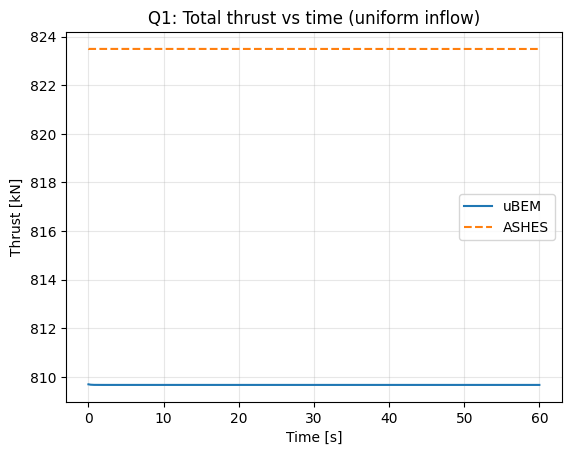

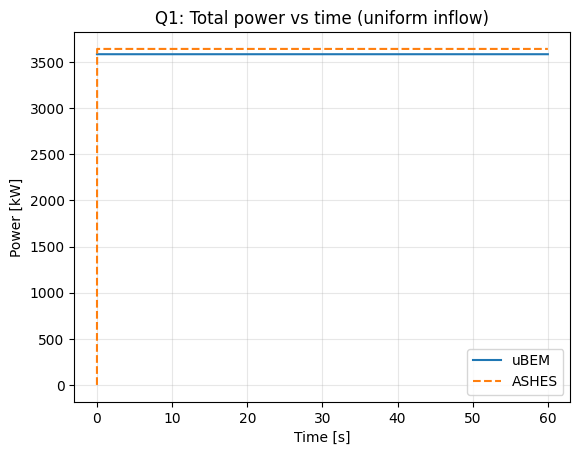

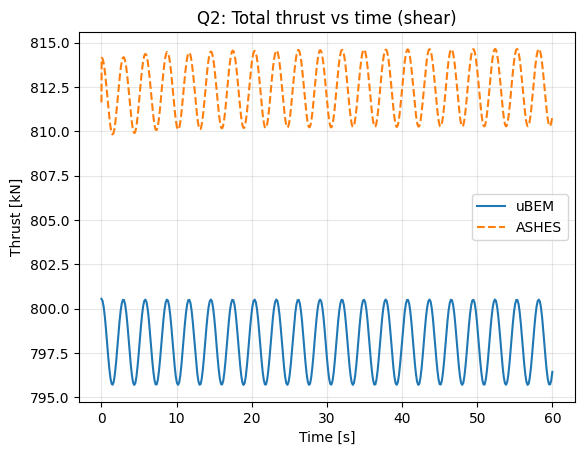

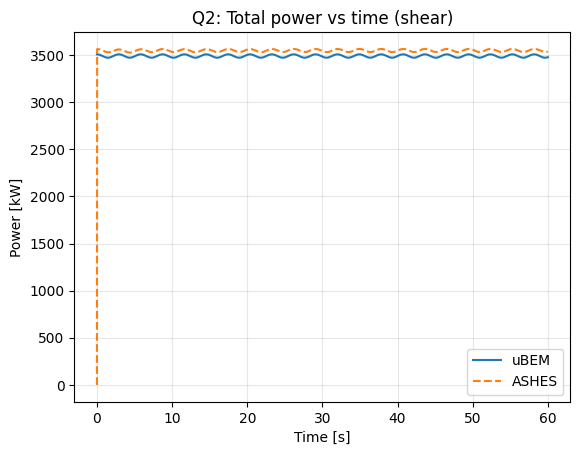

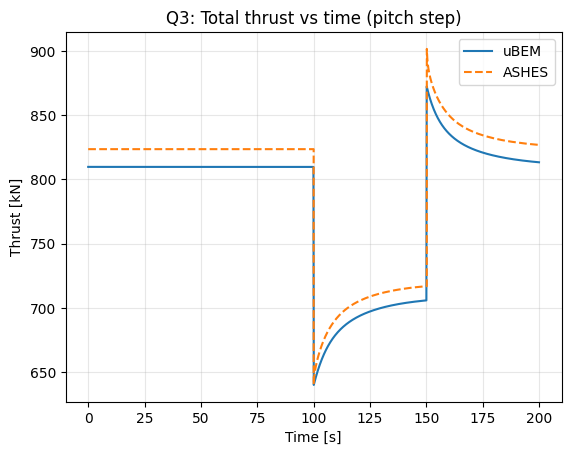

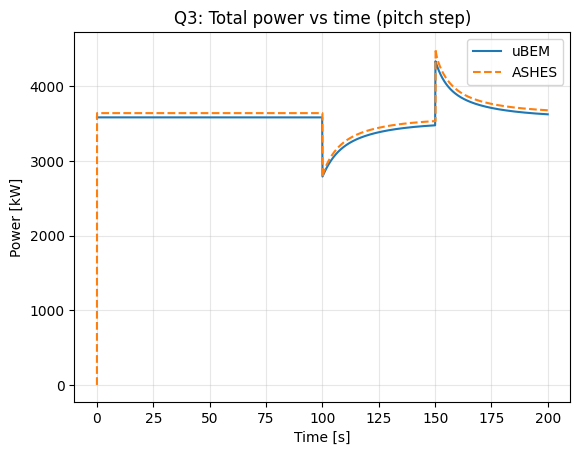

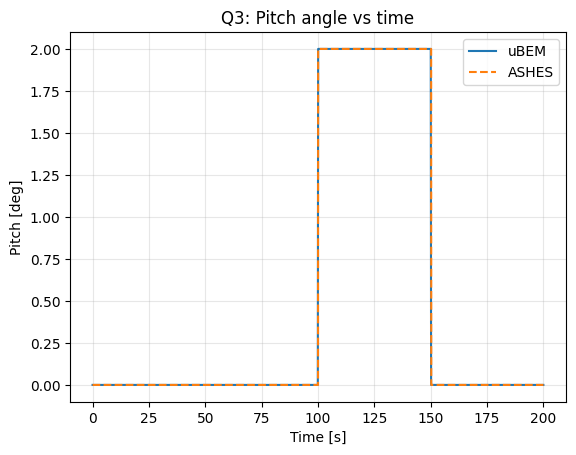

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Robust ASHES .txt loader
# -----------------------------
def load_ashes_rotor_txt(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("Time") and "Time [s]" in ln:
            header_idx = i
            break

    colnames = lines[header_idx].strip().split("\t")

    data_start = None
    for i in range(header_idx + 1, len(lines)):
        s = lines[i].strip()
        if not s or s.startswith("#") or s.startswith("----"):
            continue
        if s.startswith(("Min\t", "Max\t", "Mean\t", "Standard deviation\t")):
            continue

        first = s.split("\t")[0]
        try:
            float(first)
            data_start = i
            break
        except:
            continue

    data_rows = []
    for i in range(data_start, len(lines)):
        s = lines[i].strip()
        if not s or s.startswith("#") or s.startswith("----"):
            continue
        parts = s.split("\t")
        if len(parts) < len(colnames):
            continue
        try:
            data_rows.append([float(x) for x in parts[:len(colnames)]])
        except:
            continue

    arr = np.array(data_rows)
    return {colnames[i]: arr[:, i] for i in range(len(colnames))}


# -----------------------------
# 2) Truncate time
# -----------------------------
def truncate_ashes(data, tmax):
    t = data["Time [s]"]
    mask = t <= tmax
    return {k: v[mask] for k, v in data.items()}


# -----------------------------
# 3) Plot helper
# -----------------------------
def plot_compare(t_ours, y_ours, t_ashes, y_ashes, title, ylabel):
    plt.figure()
    plt.plot(t_ours, y_ours, label="uBEM")
    plt.plot(t_ashes, y_ashes, "--", label="ASHES")
    plt.xlabel("Time [s]")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()


# -----------------------------
# 4) Load ASHES data
# -----------------------------
ashes_q1 = load_ashes_rotor_txt("Q1 Rotor.txt")
ashes_q2 = load_ashes_rotor_txt("Q2 Rotor.txt")
ashes_q3 = load_ashes_rotor_txt("Q3 Rotor.txt")


# -----------------------------
# 5) Truncate to correct simulation lengths
# -----------------------------
ashes_q1 = truncate_ashes(ashes_q1, 60)
ashes_q2 = truncate_ashes(ashes_q2, 60)
ashes_q3 = truncate_ashes(ashes_q3, 200)


# -----------------------------
# 6) Q1 comparison
# -----------------------------
plot_compare(
    out1["t"], out1["T_total"]/1e3,
    ashes_q1["Time [s]"], ashes_q1["Thrust (aero) [k N]"],
    "Q1: Total thrust vs time (uniform inflow)",
    "Thrust [kN]"
)

plot_compare(
    out1["t"], out1["P_total"]/1e3,
    ashes_q1["Time [s]"], ashes_q1["Power (aero) [k W]"],
    "Q1: Total power vs time (uniform inflow)",
    "Power [kW]"
)


# -----------------------------
# 7) Q2 comparison
# -----------------------------
plot_compare(
    out2["t"], out2["T_total"]/1e3,
    ashes_q2["Time [s]"], ashes_q2["Thrust (aero) [k N]"],
    "Q2: Total thrust vs time (shear)",
    "Thrust [kN]"
)

plot_compare(
    out2["t"], out2["P_total"]/1e3,
    ashes_q2["Time [s]"], ashes_q2["Power (aero) [k W]"],
    "Q2: Total power vs time (shear)",
    "Power [kW]"
)


# -----------------------------
# 8) Q3 comparison
# -----------------------------
plot_compare(
    out3["t"], out3["T_total"]/1e3,
    ashes_q3["Time [s]"], ashes_q3["Thrust (aero) [k N]"],
    "Q3: Total thrust vs time (pitch step)",
    "Thrust [kN]"
)

plot_compare(
    out3["t"], out3["P_total"]/1e3,
    ashes_q3["Time [s]"], ashes_q3["Power (aero) [k W]"],
    "Q3: Total power vs time (pitch step)",
    "Power [kW]"
)


# Optional pitch comparison
pitch_col = "Representative demanded pitch angle [°]"
if pitch_col in ashes_q3:
    plot_compare(
        out3["t"], out3["pitch_deg"],
        ashes_q3["Time [s]"], ashes_q3[pitch_col],
        "Q3: Pitch angle vs time",
        "Pitch [deg]"
    )

plt.show()

### Comparison Q4

THRUST OURS  mean/std [kN]: 801.36 / 44.1811
THRUST ASHES mean/std [kN]: 867.808 / 103.508
POWER OURS  mean/std [kW]: 3538.58 / 498.553
POWER ASHES mean/std [kW]: 4419.76 / 1215.34

LOCAL LOAD: Skipped (could not find a matching N/m local-load column in ASHES).


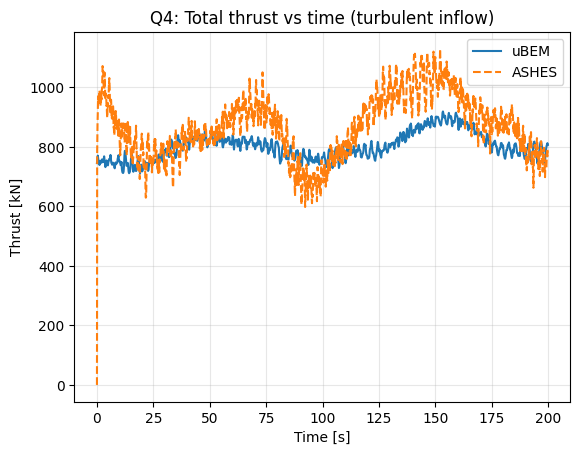

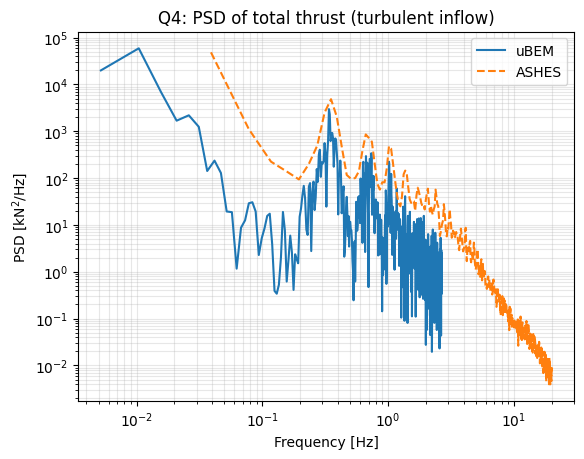

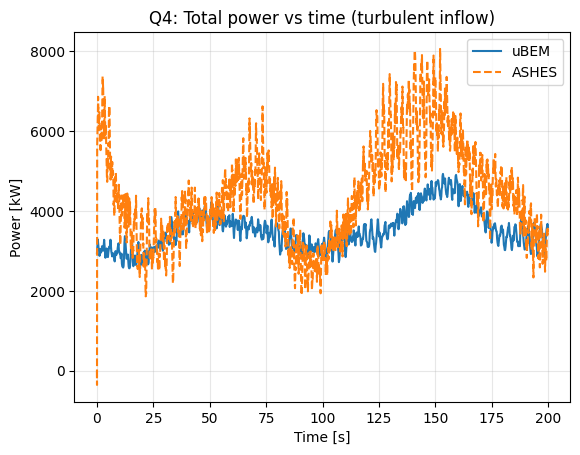

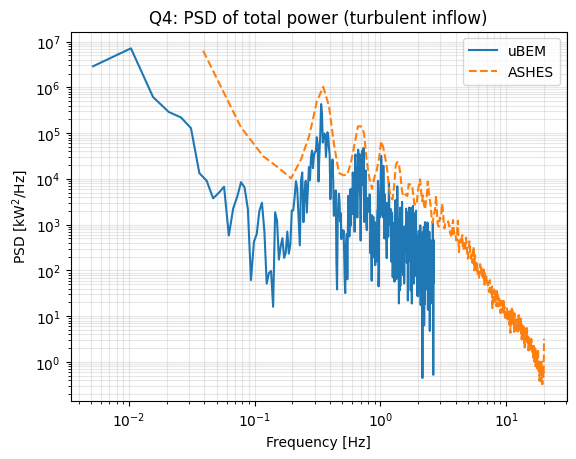

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Q4: ASHES comparison code (Thrust + optional Power + optional local load + PSD)
# Assumes:
#   - you already computed: out4 = run_Q4(...)
#   - you have an ASHES file like: "Rotor_turbulence_SimBin.txt" (or Mann)
# This cell will:
#   1) load ASHES rotor sensor txt
#   2) crop both signals to the same time window
#   3) plot: thrust(t), power(t) [if available], local load(t) [if available]
#   4) plot: PSD(thrust), PSD(power) [if available], PSD(local load) [if available]
#   5) print mean/std for each compared signal
# ============================================================

# -----------------------------
# 1) Robust ASHES .txt loader
# -----------------------------
def load_ashes_rotor_txt(path):
    """
    Loads an ASHES 'Sensor: Rotor' text file (tab-separated) and returns:
      dict {column_name: np.array}
    Handles the statistics block (Min/Max/Mean/...) and separator lines.
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # Find header line containing "Time [s]"
    header_idx = None
    for i, ln in enumerate(lines):
        s = ln.strip()
        if s.startswith("Time") and "Time [s]" in s:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find header line with 'Time [s]' in {path}")

    colnames = lines[header_idx].strip().split("\t")

    # Find start of numeric data block
    data_start = None
    for i in range(header_idx + 1, len(lines)):
        s = lines[i].strip()
        if not s or s.startswith("#") or s.startswith("----"):
            continue
        if s.startswith(("Min\t", "Max\t", "Mean\t", "Standard deviation\t")):
            continue
        # numeric line?
        first = s.split("\t")[0]
        try:
            float(first)
            if len(s.split("\t")) >= len(colnames):
                data_start = i
                break
        except Exception:
            continue

    if data_start is None:
        raise ValueError(f"Could not find numeric data block in {path}")

    rows = []
    for i in range(data_start, len(lines)):
        s = lines[i].strip()
        if not s or s.startswith("#") or s.startswith("----"):
            continue
        parts = s.split("\t")
        if len(parts) < len(colnames):
            continue
        try:
            rows.append([float(x) for x in parts[:len(colnames)]])
        except Exception:
            continue

    arr = np.array(rows, dtype=float)
    return {colnames[j]: arr[:, j] for j in range(len(colnames))}


# -----------------------------
# 2) Helpers: crop + PSD + plotting
# -----------------------------
def crop_to_tmax(t, y, tmax):
    m = (t >= 0.0) & (t <= tmax)
    return t[m], y[m]

def crop_to_overlap(t1, y1, t2, y2, tmax=None):
    tmin = max(np.min(t1), np.min(t2), 0.0)
    tmax_eff = min(np.max(t1), np.max(t2))
    if tmax is not None:
        tmax_eff = min(tmax_eff, float(tmax))
    m1 = (t1 >= tmin) & (t1 <= tmax_eff)
    m2 = (t2 >= tmin) & (t2 <= tmax_eff)
    return t1[m1], y1[m1], t2[m2], y2[m2]

def welch_psd(x, fs, nperseg=1024, noverlap=None):
    """
    Simple Welch PSD (numpy-only). Returns f [Hz], PSD [units^2/Hz].
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)

    N = len(x)
    if N < 8:
        return np.array([0.0]), np.array([0.0])

    nperseg = int(min(nperseg, N))
    if noverlap is None:
        noverlap = nperseg // 2
    noverlap = int(min(noverlap, nperseg - 1))
    step = nperseg - noverlap

    w = np.hanning(nperseg)
    U = np.sum(w**2)

    idx0 = np.arange(0, N - nperseg + 1, step)
    if idx0.size == 0:
        idx0 = np.array([0])

    psd_acc = None
    for i0 in idx0:
        seg = x[i0:i0 + nperseg] * w
        X = np.fft.rfft(seg)
        P = (np.abs(X) ** 2) / (fs * U)
        psd_acc = P if psd_acc is None else psd_acc + P

    psd = psd_acc / float(len(idx0))
    f = np.fft.rfftfreq(nperseg, d=1.0 / fs)
    return f, psd

def plot_compare_time(t_ours, y_ours, t_ash, y_ash, title, ylabel, ours_label="uBEM", ashes_label="ASHES"):
    plt.figure()
    plt.plot(t_ours, y_ours, label=ours_label)
    plt.plot(t_ash, y_ash, "--", label=ashes_label)
    plt.xlabel("Time [s]")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()

def plot_compare_psd(y_ours, fs_ours, y_ash, fs_ash, title, ylabel):
    f1, P1 = welch_psd(y_ours, fs_ours, nperseg=1024)
    f2, P2 = welch_psd(y_ash, fs_ash, nperseg=1024)
    plt.figure()
    # skip f=0 for loglog
    plt.loglog(f1[1:], P1[1:], label="uBEM")
    plt.loglog(f2[1:], P2[1:], "--", label="ASHES")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()

def print_stats(name, y_ours, y_ash, unit=""):
    mu1, sd1 = float(np.mean(y_ours)), float(np.std(y_ours))
    mu2, sd2 = float(np.mean(y_ash)),  float(np.std(y_ash))
    print(f"{name} OURS  mean/std {unit}: {mu1:.6g} / {sd1:.6g}")
    print(f"{name} ASHES mean/std {unit}: {mu2:.6g} / {sd2:.6g}")


# -----------------------------
# 3) Column finder for ASHES (robust to naming variations)
# -----------------------------
def find_col(data_dict, candidates):
    """
    Return the first column name in data_dict that matches any candidate exactly.
    """
    for c in candidates:
        if c in data_dict:
            return c
    return None

def find_col_contains(data_dict, must_contain_all=(), must_contain_any=()):
    """
    Return first column that contains all strings in must_contain_all AND
    at least one string in must_contain_any (if provided).
    """
    keys = list(data_dict.keys())
    for k in keys:
        ok_all = all(s in k for s in must_contain_all)
        ok_any = True if not must_contain_any else any(s in k for s in must_contain_any)
        if ok_all and ok_any:
            return k
    return None


# ============================================================
# 4) RUN Q4 COMPARISON
# ============================================================
# ---- edit this filename if needed ----
ASHES_Q4_FILE = "Rotor_turbulence_SimBin.txt"  # or "Rotor_turbulence_Mann.txt"

ashes_q4 = load_ashes_rotor_txt(ASHES_Q4_FILE)

# ---- time vectors ----
t_ours_full = out4["t"]  # seconds
t_ash_full  = ashes_q4["Time [s]"]

# ---- Choose matching time window: use our simulation duration (typically 200 s) ----
tmax = float(np.max(t_ours_full))
t_ours = t_ours_full
t_ash  = t_ash_full

# ---- Sampling frequencies for PSD ----
# Our Q4 uses frozen turbulence dt_q4 stored in out4
fs_ours = float(out4.get("fs_q4", 1.0 / float(np.mean(np.diff(t_ours_full)))))
fs_ash  = 1.0 / float(np.mean(np.diff(t_ash_full)))  # estimate from ASHES time vector

# ============================================================
# A) THRUST comparison (always)
# ============================================================
# Our thrust is N -> kN
yT_ours = out4["T_total"] / 1e3

# ASHES thrust could be either [k N] or [N]
col_thrust = find_col(ashes_q4, ["Thrust (aero) [k N]", "Thrust (aero) [kN]", "Thrust (aero) [N]"])
if col_thrust is None:
    # fallback: try contains
    col_thrust = find_col_contains(ashes_q4, must_contain_all=("Thrust",), must_contain_any=("aero",))

if col_thrust is None:
    raise KeyError("Could not find a thrust column in ASHES Q4 file. Check column names in ashes_q4.keys().")

yT_ash = ashes_q4[col_thrust]
# If ASHES is in N, convert to kN
if "[N]" in col_thrust and "[k" not in col_thrust:
    yT_ash = yT_ash / 1e3

# Crop both to common time interval (0..tmax of ours)
t_ours_T, yT_ours_c, t_ash_T, yT_ash_c = crop_to_overlap(t_ours, yT_ours, t_ash, yT_ash, tmax=tmax)

plot_compare_time(
    t_ours_T, yT_ours_c,
    t_ash_T,  yT_ash_c,
    title="Q4: Total thrust vs time (turbulent inflow)",
    ylabel="Thrust [kN]"
)
print_stats("THRUST", yT_ours_c, yT_ash_c, unit="[kN]")

plot_compare_psd(
    yT_ours_c, fs_ours,
    yT_ash_c,  fs_ash,
    title="Q4: PSD of total thrust (turbulent inflow)",
    ylabel=r"PSD [kN$^2$/Hz]"
)

# ============================================================
# B) POWER comparison (optional, only if available in both)
# ============================================================
if "P_total" in out4:
    yP_ours = out4["P_total"] / 1e3  # W -> kW

    col_power = find_col(ashes_q4, ["Power (aero) [k W]", "Power (aero) [kW]", "Power (aero) [W]"])
    if col_power is None:
        col_power = find_col_contains(ashes_q4, must_contain_all=("Power",), must_contain_any=("aero",))

    if col_power is not None:
        yP_ash = ashes_q4[col_power]
        if "[W]" in col_power and "[k" not in col_power:
            yP_ash = yP_ash / 1e3  # W -> kW

        t_ours_P, yP_ours_c, t_ash_P, yP_ash_c = crop_to_overlap(t_ours, yP_ours, t_ash, yP_ash, tmax=tmax)

        plot_compare_time(
            t_ours_P, yP_ours_c,
            t_ash_P,  yP_ash_c,
            title="Q4: Total power vs time (turbulent inflow)",
            ylabel="Power [kW]"
        )
        print_stats("POWER", yP_ours_c, yP_ash_c, unit="[kW]")

        plot_compare_psd(
            yP_ours_c, fs_ours,
            yP_ash_c,  fs_ash,
            title="Q4: PSD of total power (turbulent inflow)",
            ylabel=r"PSD [kW$^2$/Hz]"
        )
    else:
        print("\nPOWER: Skipped (no Power column found in ASHES file).")

# ============================================================
# C) LOCAL LOAD comparison at r=65.75 (optional)
# ============================================================
# Our local is pz_probe [N/m] -> keep as N/m (or convert to kN/m if you prefer)
if "pz_probe" in out4:
    ypz_ours = out4["pz_probe"]  # N/m

    # ASHES may or may not have the exact same sensor.
    # Try common patterns (you can print keys if it fails).
    col_pz = find_col(ashes_q4, [
        "pz(r=65.75 m) [N/m] (blade 1)",
        "pz(r=65.75 m) [N/m]",
        "Load normal to rotor plane at r=65.75 m [N/m]"
    ])
    if col_pz is None:
        # fallback: look for something that contains N/m and might be normal load
        col_pz = find_col_contains(ashes_q4, must_contain_all=("[N/m]",), must_contain_any=("pz", "normal", "rotor plane"))

    if col_pz is not None:
        ypz_ash = ashes_q4[col_pz]  # assume N/m already

        t_ours_z, ypz_ours_c, t_ash_z, ypz_ash_c = crop_to_overlap(t_ours, ypz_ours, t_ash, ypz_ash, tmax=tmax)

        plot_compare_time(
            t_ours_z, ypz_ours_c,
            t_ash_z,  ypz_ash_c,
            title="Q4: Local normal load vs time (r=65.75 m)",
            ylabel="Load [N/m]"
        )
        print_stats("LOCAL LOAD", ypz_ours_c, ypz_ash_c, unit="[N/m]")

        plot_compare_psd(
            ypz_ours_c, fs_ours,
            ypz_ash_c,  fs_ash,
            title="Q4: PSD of local normal load (r=65.75 m)",
            ylabel=r"PSD [(N/m)$^2$/Hz]"
        )
    else:
        print("\nLOCAL LOAD: Skipped (could not find a matching N/m local-load column in ASHES).")
        # Uncomment to inspect available columns:
        # print("ASHES columns:", list(ashes_q4.keys()))

plt.show()